# Linear Regression

In [4]:
# imports
import math
import numpy as np 
import matplotlib.pyplot as plt 

from nnfs.datasets import sine_data

np.random.seed(67)

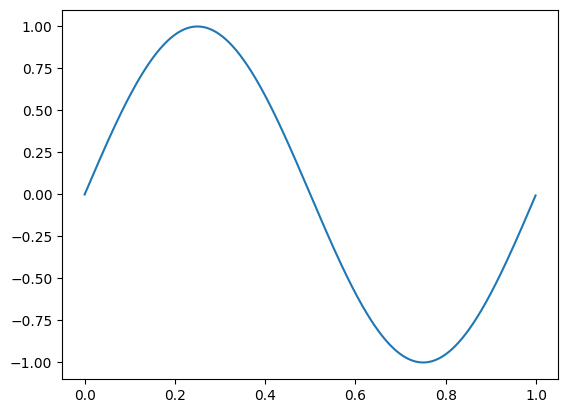

In [4]:
# We will be using sine wave as example in this notebook
X, y = sine_data()
plt.plot(X, y)
plt.show()

# Initialize Current Code

In [1]:
class Layer_Dense:
    def __init__(self, n_inputs, n_neurons,
                 weight_regularizer_l1=0, bias_regularizer_l1=0,
                 weight_regularizer_l2=0, bias_regularizer_l2=0):
        self.weights = 0.10 * np.random.randn(n_inputs, n_neurons)
        self.biases = np.zeros((1, n_neurons))

        # initialize here
        self.weight_regularizer_l1 = weight_regularizer_l1
        self.bias_regularizer_l1 = bias_regularizer_l1
        self.weight_regularizer_l2 = weight_regularizer_l2
        self.bias_regularizer_l2 = bias_regularizer_l2        

    def forward(self, inputs):
        self.inputs = inputs 
        self.output = np.dot(inputs, self.weights) + self.biases

    def backward(self, dvalues):
        self.dweights = np.dot(self.inputs.T, dvalues) 
        self.dbiases = np.sum(dvalues, axis=0, keepdims=True)         

        # backwards pass
        # integrate l1 regularizer here
        if self.weight_regularizer_l1 > 0:
            dL1 = np.ones_like(self.weights)
            dL1[self.weights < 0] = -1
            self.dweights += self.weight_regularizer_l1 * dL1
        if self.bias_regularizer_l1 > 0:
            dL1 = np.ones_like(self.biases)
            dL1[self.biases < 0] = -1
            self.dbiases += self.bias_regularizer_l1 * dL1

        # integrate l2 regularizer here
        if self.weight_regularizer_l2 > 0:
            self.dweights += 2 * self.weight_regularizer_l2 * self.weights
        if self.bias_regularizer_l2 > 0:
            self.dbiases += 2 * self.bias_regularizer_l2 * self.biases

        self.dinputs = np.dot(dvalues, self.weights.T)

class Activation_ReLU: 
    def forward(self, inputs): 
        self.inputs = inputs 
        self.output = np.maximum(0, inputs) 

    def backward(self, dvalues): 
        self.dinputs = dvalues.copy() 
        self.dinputs[self.inputs <= 0] = 0 

class Activation_Softmax: 
    def forward(self, inputs): 
        self.inputs = inputs 
        exp_values = np.exp(inputs - np.max(inputs, axis=1, keepdims=True)) 
        probabilities = exp_values / np.sum(exp_values, axis=1, keepdims=True) 
        self.output = probabilities 

    def backward(self, dvalues): 
        self.dinputs = np.empty_like(dvalues) 
 
        for index, (single_output, single_dvalues) in enumerate(zip(self.output, dvalues)): 
            single_output = single_output.reshape(-1, 1) 
            jacobian_matrix = np.diagflat(single_output) - np.dot(single_output, single_output.T) 

            self.dinputs[index] = np.dot(jacobian_matrix, 
                                         single_dvalues) 

class Optimizer_Adam: 
    def __init__(self, learning_rate=0.001, decay=0., epsilon=1e-7, beta_1=0.9, beta_2=0.999): 
        self.learning_rate = learning_rate 
        self.current_learning_rate = learning_rate 
        self.decay = decay 
        self.iterations = 0 
        self.epsilon = epsilon 
        self.beta_1 = beta_1 
        self.beta_2 = beta_2 
 
    def pre_update_params(self): 
        if self.decay: 
            self.current_learning_rate = self.learning_rate * (1. / (1. + self.decay * self.iterations)) 
 
    def update_params(self, layer): 
 
        if not hasattr(layer, 'weight_cache'): 
            layer.weight_momentums = np.zeros_like(layer.weights) 
            layer.weight_cache = np.zeros_like(layer.weights) 
            layer.bias_momentums = np.zeros_like(layer.biases) 
            layer.bias_cache = np.zeros_like(layer.biases) 
 
        layer.weight_momentums = self.beta_1 * layer.weight_momentums + (1 - self.beta_1) * layer.dweights 
        layer.bias_momentums = self.beta_1 * layer.bias_momentums + (1 - self.beta_1) * layer.dbiases 

        weight_momentums_corrected = layer.weight_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 
        bias_momentums_corrected = layer.bias_momentums / (1 - self.beta_1 ** (self.iterations + 1)) 

        layer.weight_cache = self.beta_2 * layer.weight_cache + (1 - self.beta_2) * layer.dweights**2 
        layer.bias_cache = self.beta_2 * layer.bias_cache + (1 - self.beta_2) * layer.dbiases**2 

        weight_cache_corrected = layer.weight_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
        bias_cache_corrected = layer.bias_cache / (1 - self.beta_2 ** (self.iterations + 1)) 
 
        layer.weights += -self.current_learning_rate * weight_momentums_corrected / (np.sqrt(weight_cache_corrected) + self.epsilon) 
        layer.biases += -self.current_learning_rate * bias_momentums_corrected / (np.sqrt(bias_cache_corrected) + self.epsilon) 
 
    def post_update_params(self): 
        self.iterations += 1 

# Linear Activation and MSE

### MSE

$$L_i = \frac{1}{J} \sum_{j} (y_{i,j} - \hat{y}_{i,j})^2$$

### Derived

$$\frac{\partial L_i}{\partial \hat{y}_{i,j}} = \frac{2}{J}(y_{i,j} - \hat{y}_{i,j})$$

Where $\hat{y}$ are the y predictions, and $y$ are the y true values.

In [16]:
class Loss:
    def regularization_loss(self, layer):
        regularization_loss = 0

        if layer.weight_regularizer_l1 > 0:
            regularization_loss += layer.weight_regularizer_l1 * np.sum(abs(layer.weights))
        if layer.bias_regularizer_l1 > 0:
            regularization_loss += layer.bias_regularizer_l1 * np.sum(abs(layer.biases))
        if layer.weight_regularizer_l2 > 0:
            regularization_loss += layer.weight_regularizer_l2 * np.sum(layer.weights ** 2)
        if layer.bias_regularizer_l2 > 0:
            regularization_loss += layer.bias_regularizer_l2 * np.sum(layer.biases ** 2)
        
        return regularization_loss

    def calculate(self, output, y):
        sample_losses = self.forward(output, y)
        data_loss = np.mean(sample_losses)
        return data_loss
    
class Activation_Linear:
    def foward(self, inputs):
        # pass through inputs linearly
        self.inputs = inputs
        self.output = inputs
    def backward(self, dvalues):
        # derivative of 1 is 1 so we just take the copy of the dvalues
        self.dinputs = dvalues.copy()
    
class Loss_MeanSquareError(Loss):
    def forward(self, y_pred, y_true):

        # MSE loss
        sample_losses = np.mean((y_true - y_pred) ** 2, axis=-1)
        return sample_losses
    
    def backward(self, dvalues, y_true):
        samples = len(y_true)

        outputs = len(dvalues[0])

        self.dinputs = -2 * (y_true - dvalues) / outputs
        
        # normalize gradient
        self.dinputs = self.dinputs / samples

# Evaluating Linear Model

In [30]:

X, y = sine_data()

dense1 = Layer_Dense(1, 64)
activation1 = Activation_ReLU()
dense2 = Layer_Dense(64, 1)
activation2 = Activation_Linear()
loss_fn = Loss_MeanSquareError()
optimizer = Optimizer_Adam()

loss_history, accuracy_history, learning_rate_history = [], [], []

epochs = 10_000

accuracy_precision = np.std(y) / 250

for epoch in range(epochs):
    dense1.forward(X)
    activation1.forward(dense1.output)

    # pass through linear layer
    dense2.forward(activation1.output)
    activation2.foward(dense2.output)
    loss_fn.forward(activation2.output, y)

    data_loss = loss_fn.calculate(activation2.output, y)
    regularization_loss = loss_fn.regularization_loss(dense1) + loss_fn.regularization_loss(dense2)
    loss = data_loss + regularization_loss

    predictions = activation2.output 
    accuracy = np.mean(np.absolute(predictions - y) < accuracy_precision) 
 
    if epoch % (epochs // 10) == 0: 
        print(f'epoch: {epoch}, ' + 
              f'acc: {accuracy:.3f}, ' + 
              f'loss: {loss:.3f} (' + 
              f'data_loss: {data_loss:.3f}, ' + 
              f'reg_loss: {regularization_loss:.3f}), ' + 
              f'lr: {optimizer.current_learning_rate}') 
    
    loss_fn.backward(activation2.output, y)
    activation2.backward(loss_fn.dinputs)
    dense2.backward(activation2.dinputs)
    activation1.backward(dense2.dinputs)
    dense1.backward(activation1.dinputs)

    optimizer.pre_update_params()
    optimizer.update_params(dense1)
    optimizer.update_params(dense2)
    optimizer.post_update_params()

    loss_history.append(loss)
    accuracy_history.append(accuracy)
    learning_rate_history.append(optimizer.learning_rate)



epoch: 0, acc: 0.002, loss: 0.516 (data_loss: 0.516, reg_loss: 0.000), lr: 0.001
epoch: 1000, acc: 0.004, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001
epoch: 2000, acc: 0.004, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001
epoch: 3000, acc: 0.004, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001
epoch: 4000, acc: 0.003, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001
epoch: 5000, acc: 0.003, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001
epoch: 6000, acc: 0.004, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001
epoch: 7000, acc: 0.004, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001
epoch: 8000, acc: 0.003, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001
epoch: 9000, acc: 0.004, loss: 0.159 (data_loss: 0.159, reg_loss: 0.000), lr: 0.001


# Plot Data Evals

Final Values: Loss 0.15913197701598739 Accuracy 0.004 Learning Rate 0.001
Learning Rate 0.001 Decay 0.0


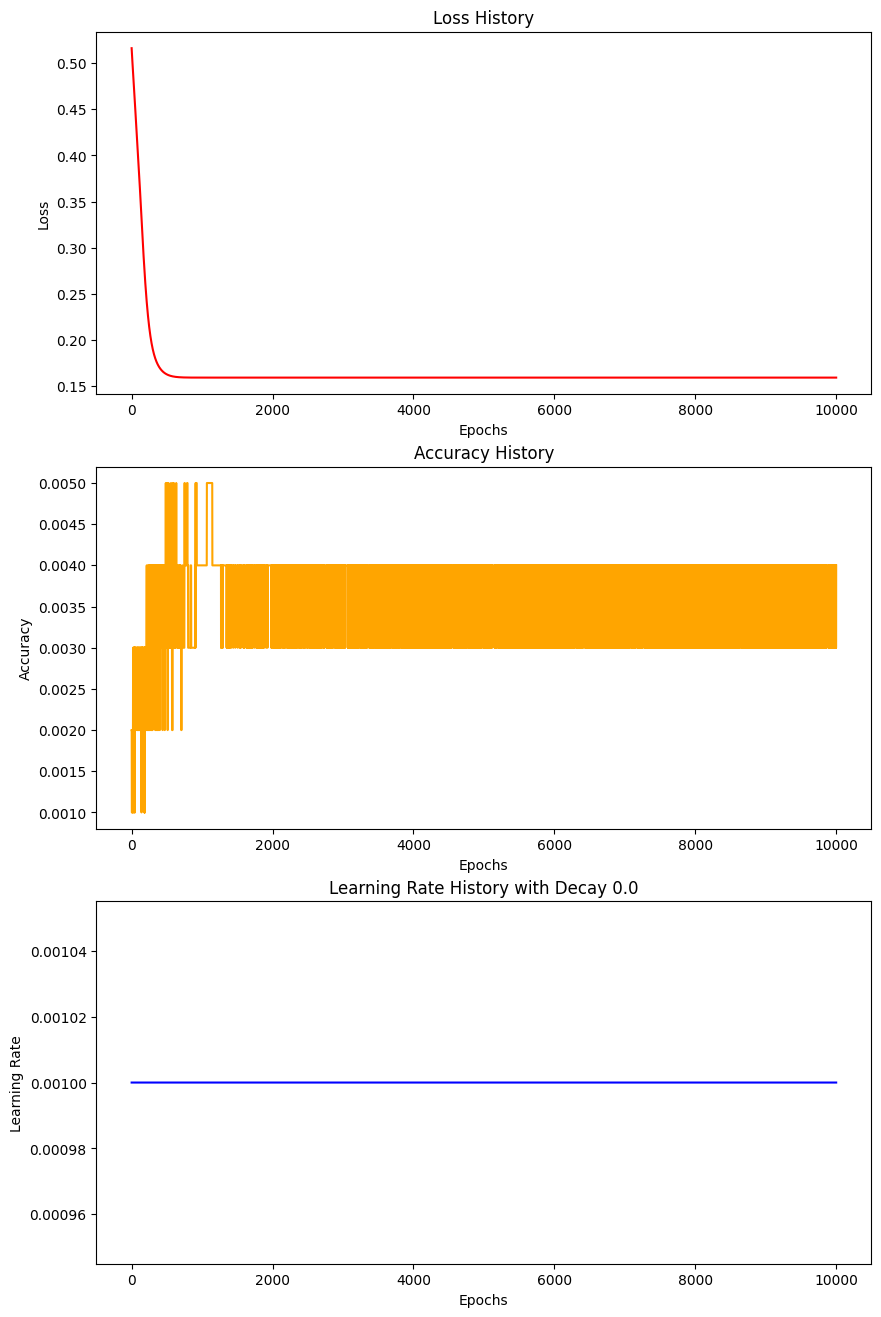

In [31]:
fig, axes = plt.subplots(nrows=3, figsize=(10, 16))

axes[0].set_title("Loss History")
axes[0].plot(loss_history, color="red")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Loss")

axes[1].set_title("Accuracy History")
axes[1].plot(accuracy_history, color="orange")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("Accuracy")

axes[2].set_title(f"Learning Rate History with Decay {optimizer.decay}")
axes[2].plot(learning_rate_history, color="blue")
axes[2].set_xlabel("Epochs")
axes[2].set_ylabel("Learning Rate")

print(f"Final Values: Loss {loss_history[-1]} Accuracy {accuracy_history[-1]} Learning Rate {learning_rate_history[-1]}")
print(f"Learning Rate {optimizer.learning_rate} Decay {optimizer.decay}")


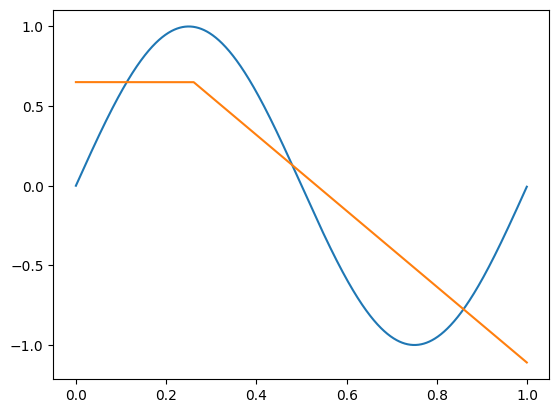

In [32]:
X_test, y_test  =  sine_data() 
dense1.forward(X_test) 
activation1.forward(dense1.output) 
dense2.forward(activation1.output) 
activation2.foward(dense2.output) 
plt.plot(X_test, y_test) 
plt.plot(X_test, activation2.output) 
plt.show() 